# Business Understanding

## Problem

The importance of real estate valuation for buyers, sellers, investors etc to assess the risk in investments and helps analysing market.

## Dataset

New Taipei City, Taiwan - Market historical data in real estate.

## Goal

1. Predict the continuoujs house price per unit area using linear regression
2. Classifying if property's price is above or below average price in the training data using logistic regression model

# Data Understanding

## Brief Description

The dataset has 414 samples with 6 features each. Features are imporant measuresements/variables for real estate price such as transaction date, house age, etc. and they're used to get Y house price of unit area.

Load initial data

In [39]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
real_estate_valuation = fetch_ucirepo(id=477) 
  
# data (as pandas dataframes) 
X = real_estate_valuation.data.features 
y = real_estate_valuation.data.targets 
  
# metadata 
print(real_estate_valuation.metadata) 
  
# variable information 
print(real_estate_valuation.variables) 


{'uci_id': 477, 'name': 'Real Estate Valuation', 'repository_url': 'https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set', 'data_url': 'https://archive.ics.uci.edu/static/public/477/data.csv', 'abstract': 'The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. ', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 414, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y house price of unit area'], 'index_col': ['No'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2018, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C5J30W', 'creators': ['I-Cheng Yeh'], 'intro_paper': {'ID': 373, 'type': 'NATIVE', 'title': 'Building real estate valuation models with comparative approach through case-based reasoning', 'authors': 'I. Yeh

Check features

# Data preparation

Numerical values of input variables are standardized using scaler. The data is split into training (70%) and test (30%) sets.

Changing the random_state will give different results

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [41]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 19.5 KB


In [42]:
X.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245


In [43]:
y.head()

,Y house price of unit area
0,37.9
1,42.2
2,47.3
3,54.8
4,43.1


# Modeling

## Linear regression

Data is modeled using linear regression, it's used to predict the continuous house price per unit area. The model is using standardized numerical data. Performance is evaluated using MSE and R2 score.

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mse, r2

(75.91168379023392, 0.5460509429839351)

MSE indicates prediction errors and model performance and rounded value would be 76 and R2 is a variance metric and the closer to 1 it is the better it is and in this case it would be rounded 0.55

In other words, this is not excellent but it's not bad - it is moderate.

Checking coefficients in columns to see how much each feature affects house price

In [45]:
b0 = model.intercept_.item()
b1 = model.coef_[0] 

print(f"Intercept (b0): {b0:.4f}")
for feature, coef in zip(X.columns, b1):
    print(f"{feature:30s}  Coefficient: {coef:.4f}")


Intercept (b0): 38.4419
X1 transaction date             Coefficient: 1.6512
X2 house age                    Coefficient: -2.7609
X3 distance to the nearest MRT station  Coefficient: -6.4044
X4 number of convenience stores  Coefficient: 3.2055
X5 latitude                     Coefficient: 2.9893
X6 longitude                    Coefficient: -0.7877


## Logistic regression

Taking average of house prices

In [46]:

mean_price = y_train.mean()
print("Training mean price:", mean_price)


Training mean price: Y house price of unit area    38.441869
dtype: float64


Here, if price is higher than average then it's 1 and if it's lower then it's 0

In [47]:
y_train_bin = (y_train > mean_price).astype(int)
y_test_bin = (y_test > mean_price).astype(int)

y_train_bin.value_counts()

Y house price of unit area
1                             154
0                             135
Name: count, dtype: int64

Making logistic regression model

In [48]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train_scaled, y_train_bin.values.ravel())

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Evaluation

# Linear regression

Code below drew the graphical statistics of predictions and actual test data. Like mentioned earlier, MSE and R2 are not the best but moderate, we can see some throw offs in the prediction in some places, for example actual data is under 10 but prediction is around 45. Only couple of predictions are far off the test data.

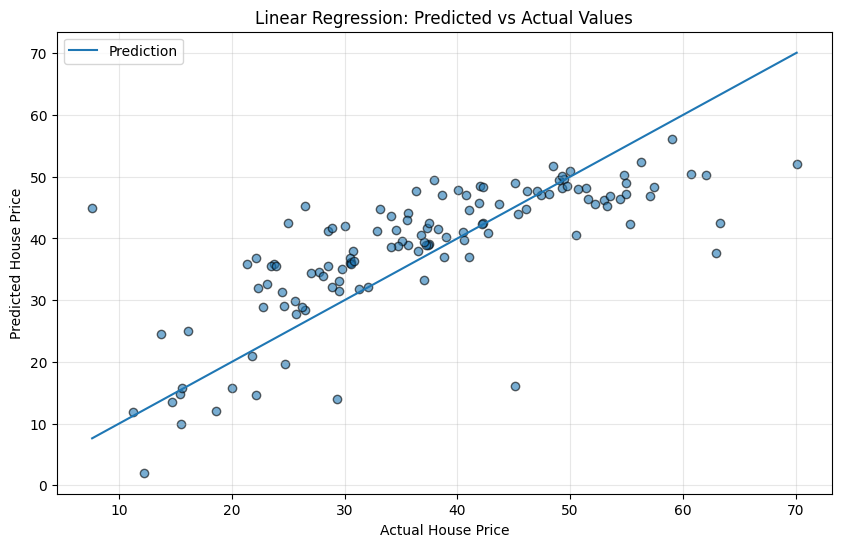

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], label='Prediction')
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Linear Regression: Predicted vs Actual Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Logistic regression

Here we draw confusion matrix of logistic regression. Accuracy is 0.79 and that means that it performed quite well.

Confusion Matrix:
Accuracy: 0.792

Confusion Matrix:
 [[50 22]
 [ 4 49]]

Report:
               precision    recall  f1-score   support

           0       0.93      0.69      0.79        72
           1       0.69      0.92      0.79        53

    accuracy                           0.79       125
   macro avg       0.81      0.81      0.79       125
weighted avg       0.83      0.79      0.79       125



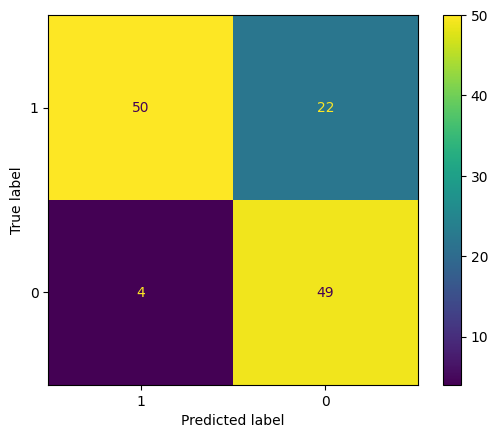

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

y_pred_bin = logreg.predict(X_test_scaled)

cm = confusion_matrix(y_test_bin, y_pred_bin)
cmd = ConfusionMatrixDisplay(cm, display_labels=["1", "0"])
print("Confusion Matrix:")
cmd.plot()


print("Accuracy:", accuracy_score(y_test_bin, y_pred_bin))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_bin, y_pred_bin))
print("\nReport:\n", classification_report(y_test_bin, y_pred_bin))

Here we draw a graphical statistics on what affects the prices the most. X3 affects the most and X6 the least.

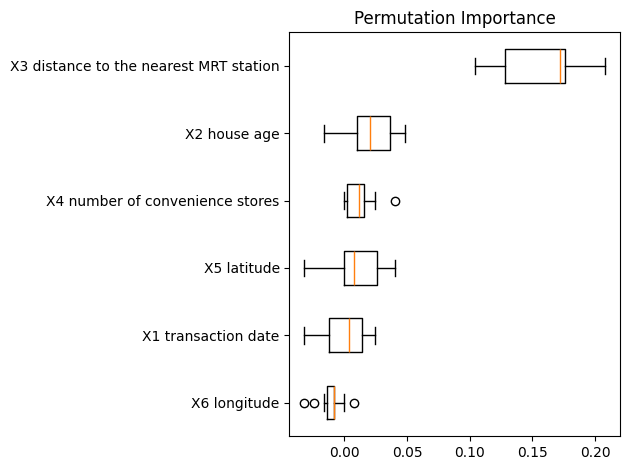

In [51]:
from sklearn.inspection import permutation_importance

result = permutation_importance(logreg, X_test_scaled, y_test_bin, n_repeats=10, scoring="accuracy", random_state=0, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots()
ax.boxplot(result.importances[sorted_idx].T, vert=False, tick_labels=X.columns[sorted_idx])
ax.set_title("Permutation Importance")
fig.tight_layout()
plt.show()

# Conclusion

With the data given, it is difficult to make very accurate predictions but it is possible to make moderate predictions.